# Fase 3 — Interpretabilidade e Inteligência Aplicada

Métrica alta não é o produto. O produto é **entender o que move o indicador** e transformar isso em
decisão. Este notebook usa Feature Importance e SHAP Values para abrir os modelos e responder às
perguntas de negócio do desafio.

In [1]:
import sys
sys.path.append("..")

import json
import pandas as pd
from IPython.display import Image, display

from src import config
from src.visualization import plots

plots.aplicar_estilo()
insights = json.loads((config.REPORTS_DIR / "insights.json").read_text(encoding="utf-8"))
eda = json.loads((config.REPORTS_DIR / "eda_estatisticas.json").read_text(encoding="utf-8"))
pd.set_option("display.width", 150)

## 1. Quais fatores mais impactam a alfabetização?

Duas leituras complementares: o **ganho** (quanto cada variável reduz o erro nas divisões das
árvores) e o **SHAP** (quanto cada variável empurra cada predição individual, com direção).

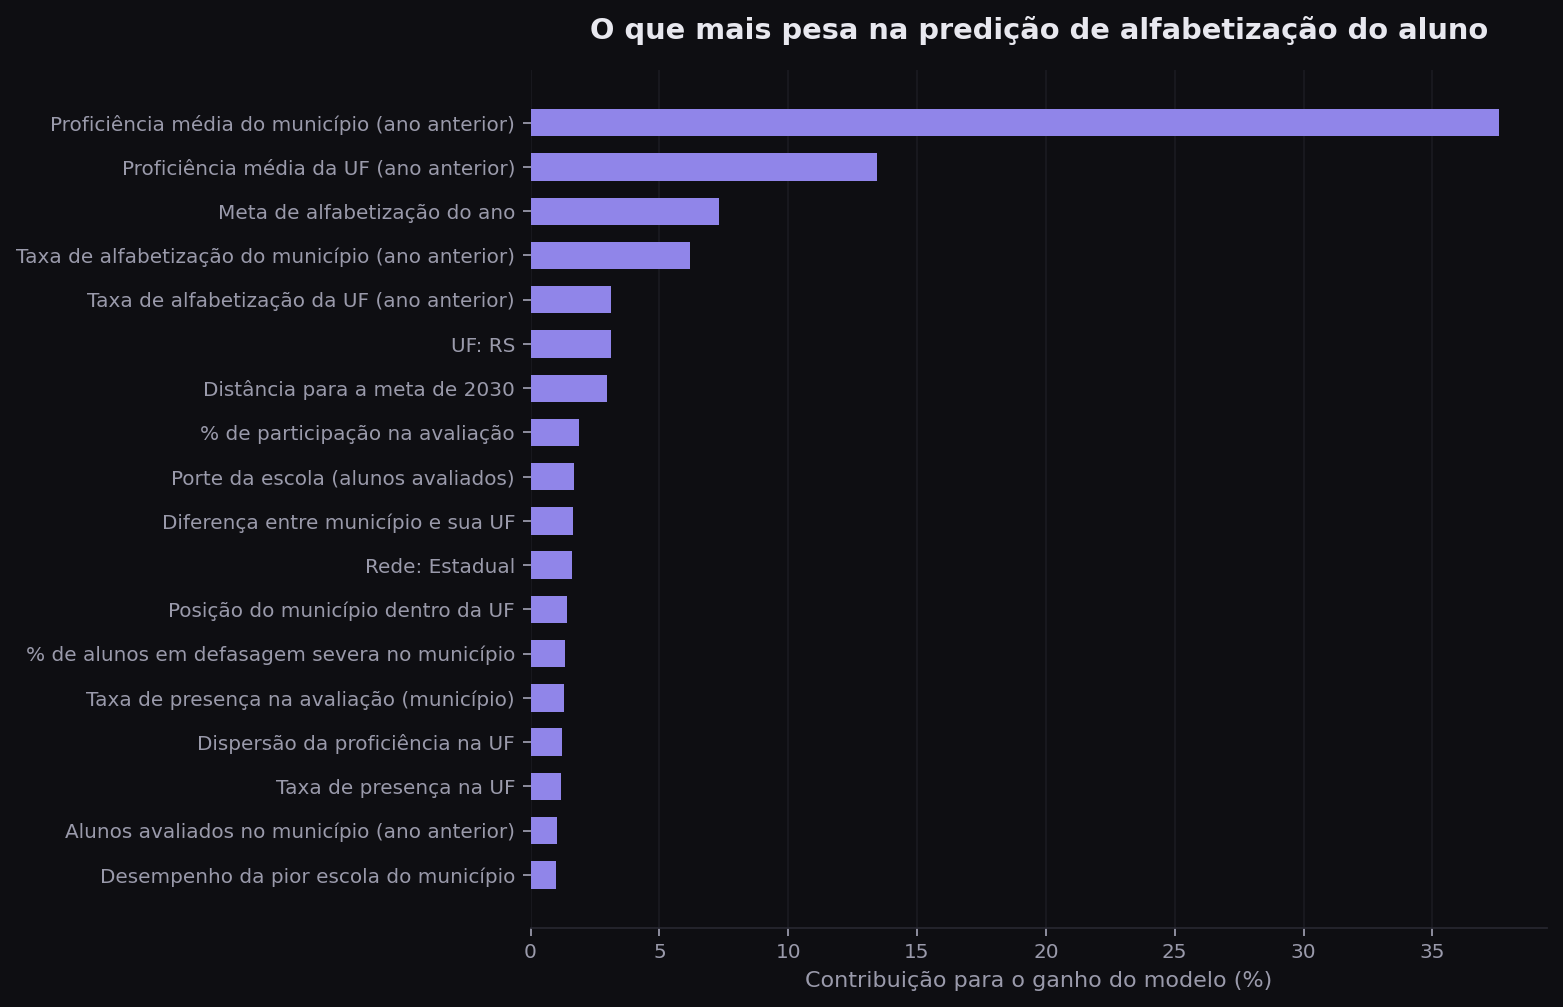

In [2]:
display(Image(filename="../images/13_aluno_importancia.png"))

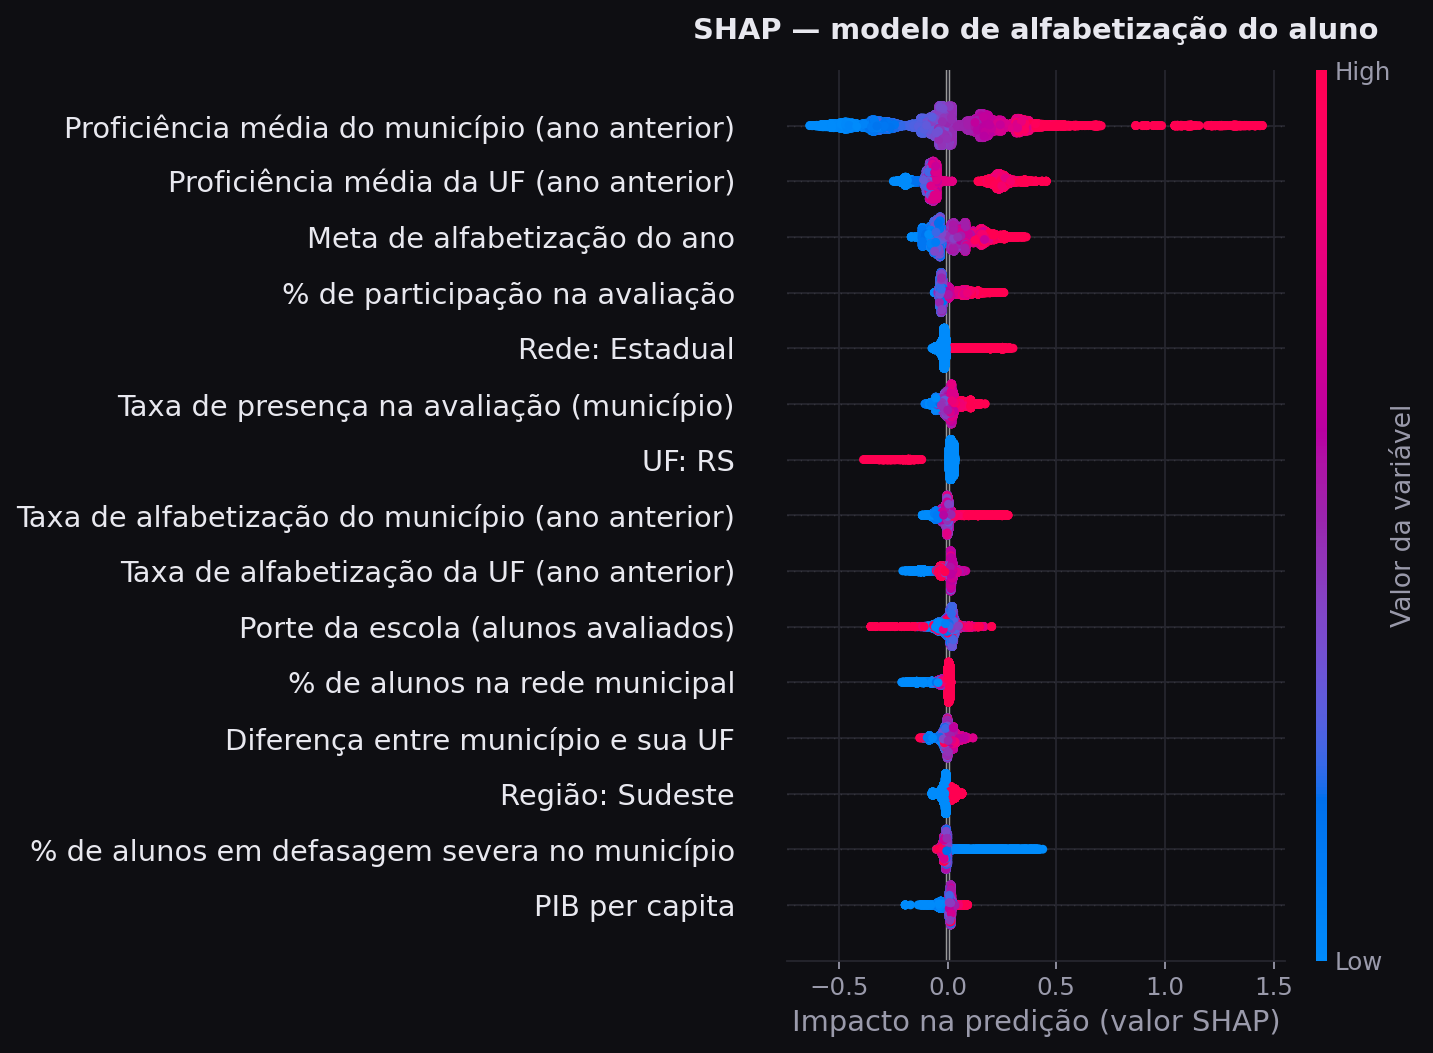

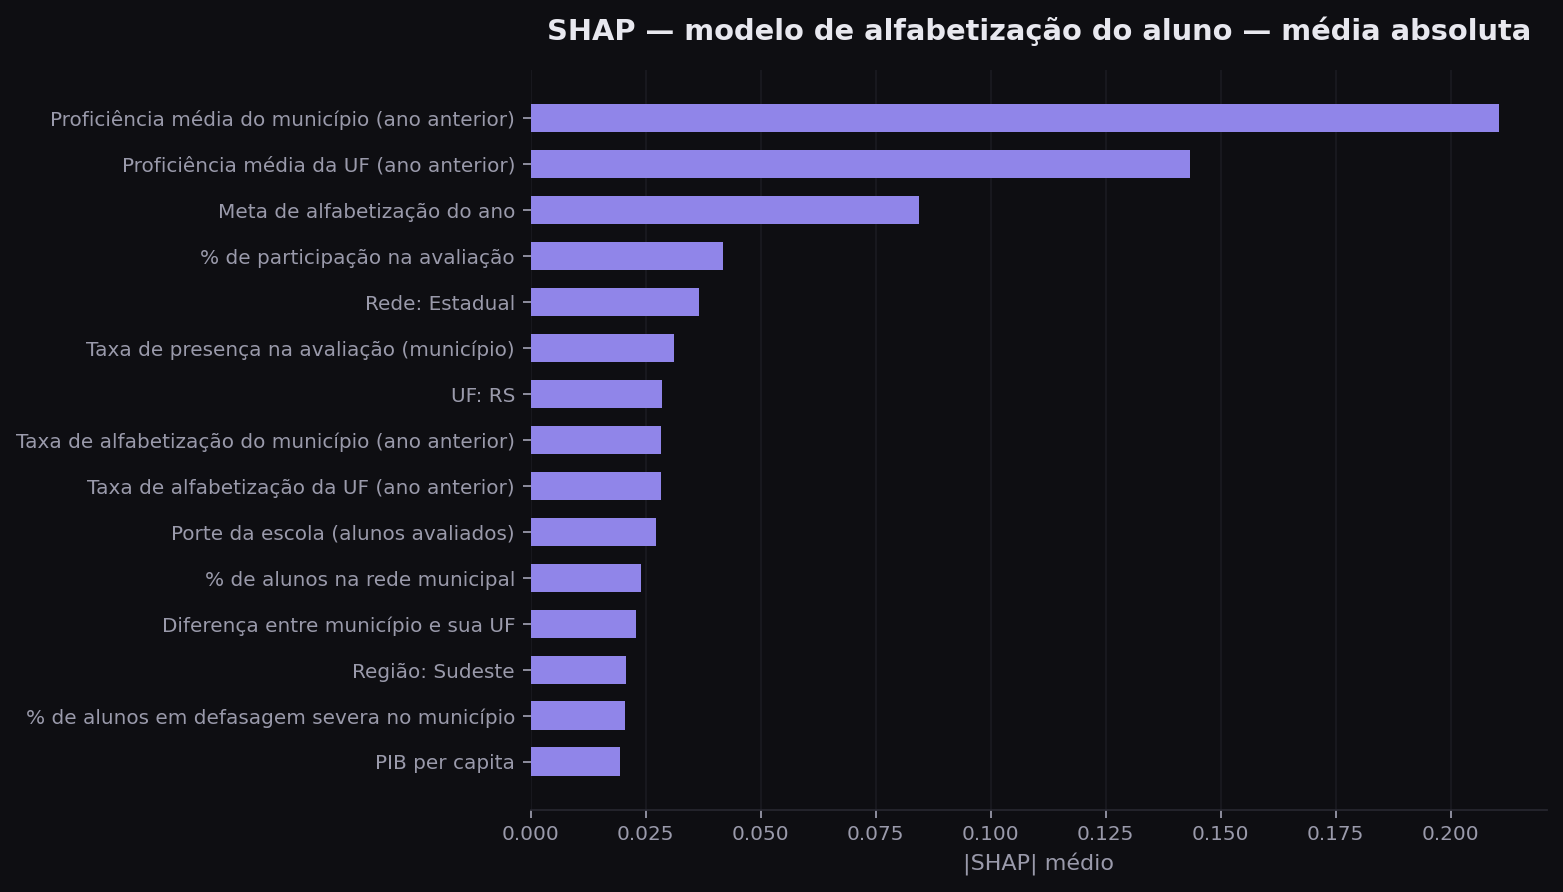

In [3]:
display(Image(filename="../images/14_aluno_shap_beeswarm.png"))
display(Image(filename="../images/14_aluno_shap_barras.png"))

In [4]:
pd.Series(insights["aluno_top_ganho"]).to_frame("contribuição para o ganho (%)").head(10)

,contribuição para o ganho (%)
Proficiência média do município (ano anterior),37.58
Proficiência média da UF (ano anterior),13.45
Meta de alfabetização do ano,7.33
Taxa de alfabetização do município (ano anterior),6.18
Taxa de alfabetização da UF (ano anterior),3.12
UF: RS,3.11
Distância para a meta de 2030,2.98
% de participação na avaliação,1.89
Porte da escola (alunos avaliados),1.70
Diferença entre município e sua UF,1.63


### Leitura

O bloco **educacional defasado** domina: a taxa de alfabetização do município no ano anterior, a
proporção de alunos em defasagem severa e a distância para a meta. Ou seja — o passado educacional
recente do território é o melhor preditor disponível do futuro de cada criança.

As variáveis **socioeconômicas** aparecem, mas em posição secundária. Confirma-se a hipótese 3 da
exploração: **renda não determina alfabetização**. Municípios com PIB per capita semelhante
apresentam resultados radicalmente diferentes — a diferença está na gestão educacional, não no
orçamento.

## 2. O que explica o risco de um município não bater a meta?

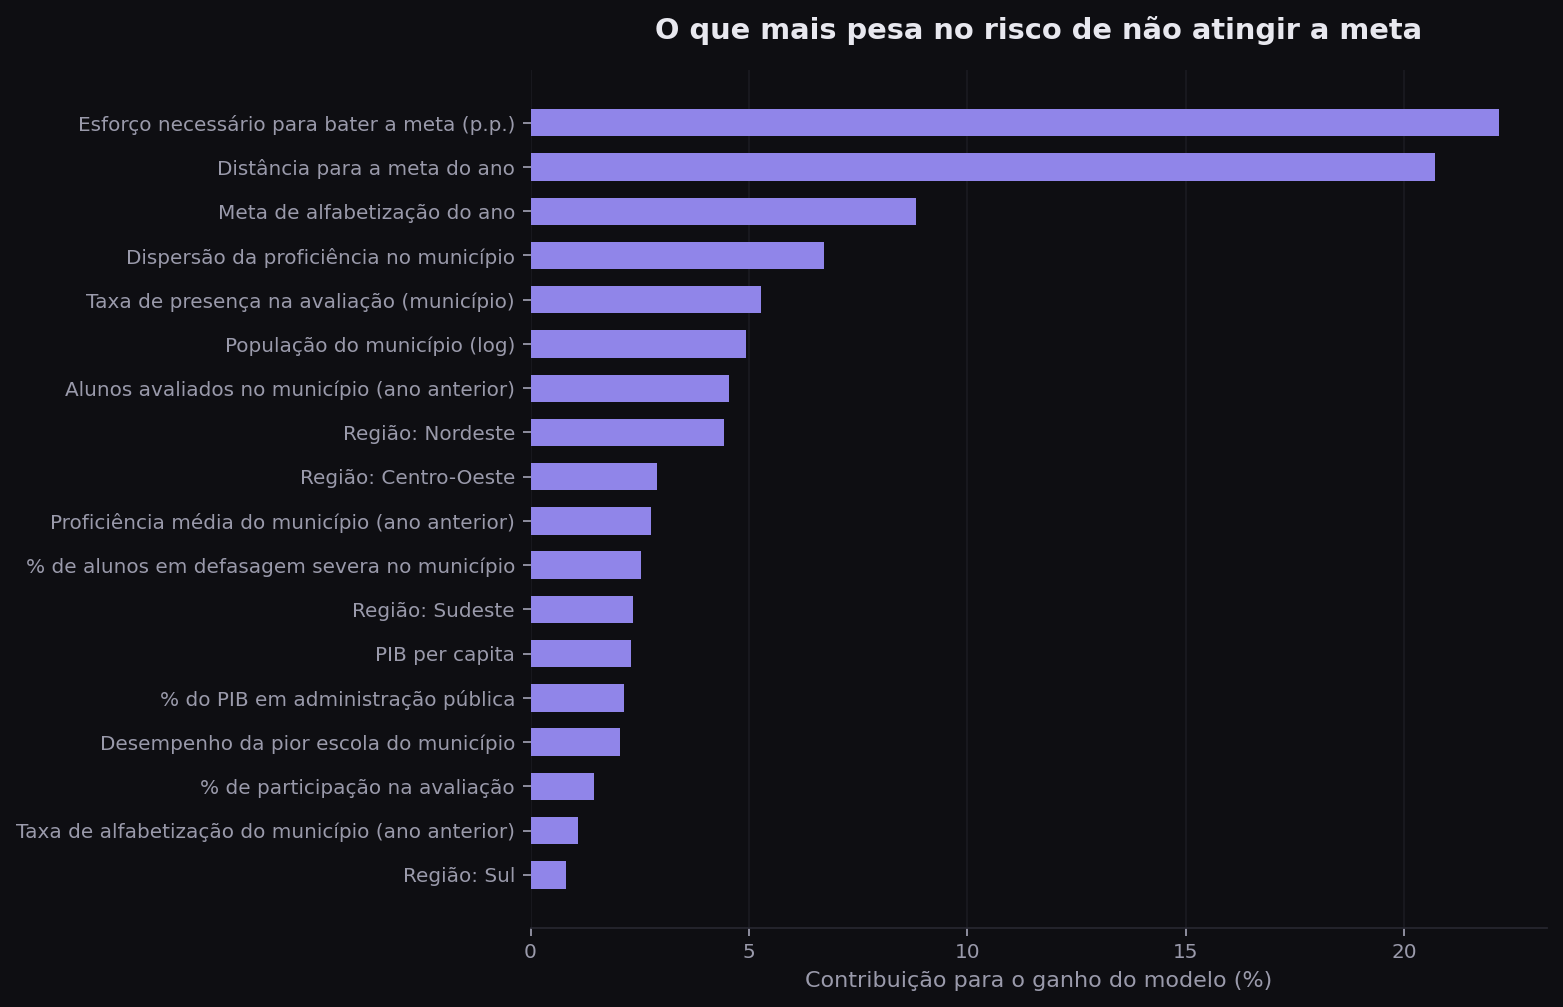

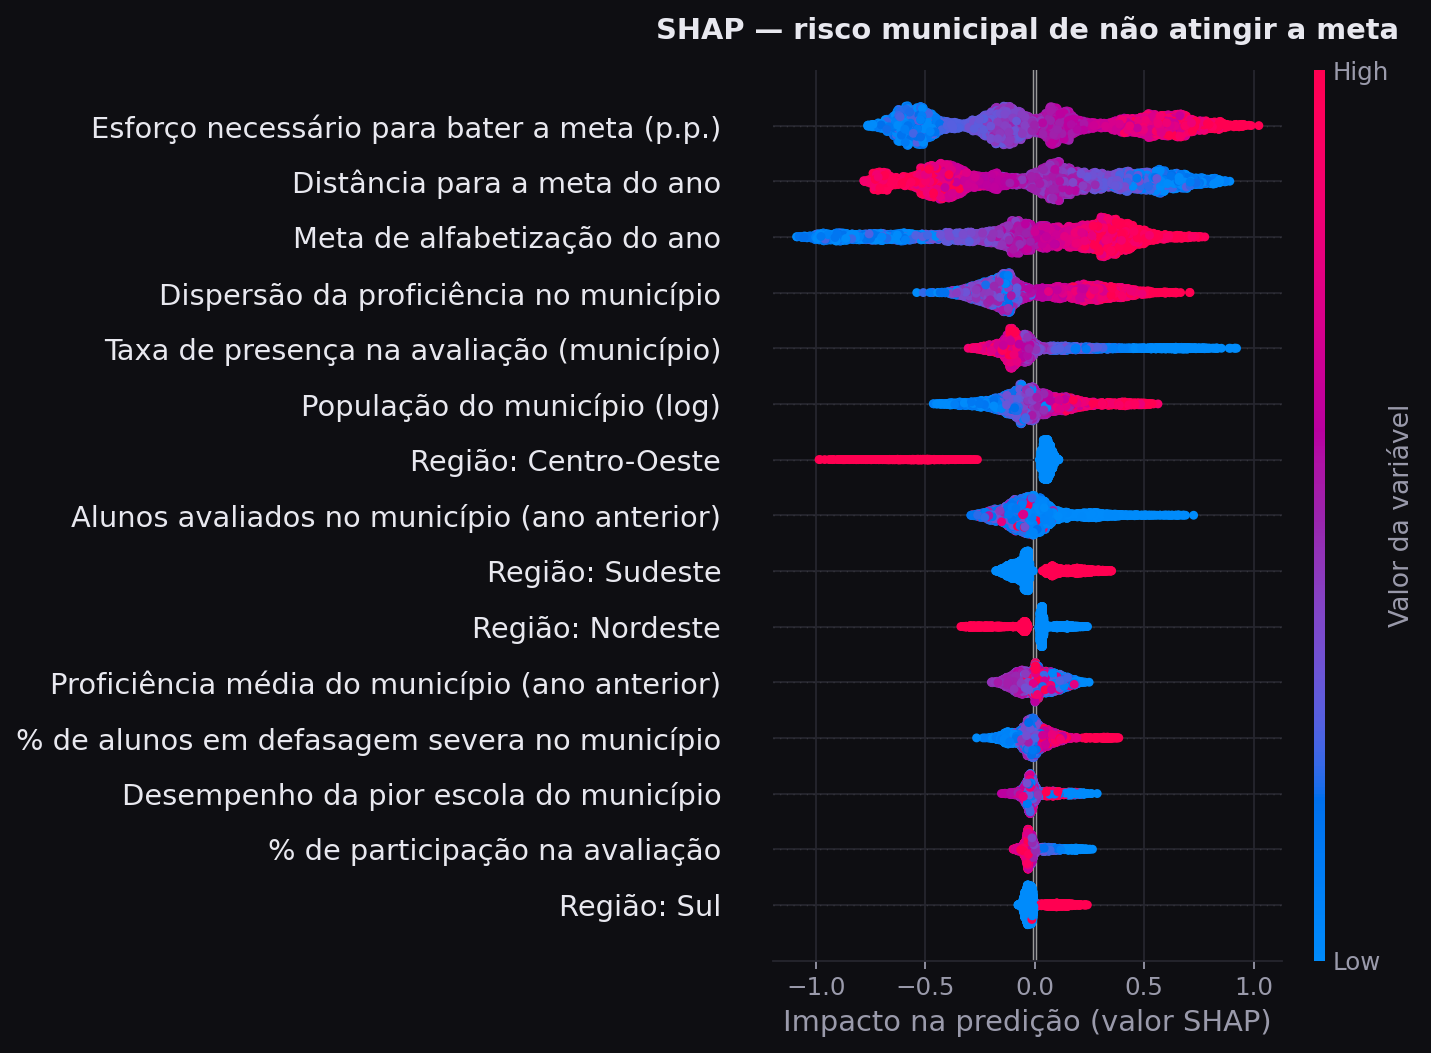

In [5]:
display(Image(filename="../images/15_municipio_importancia.png"))
display(Image(filename="../images/16_municipio_shap_beeswarm.png"))

In [6]:
pd.Series(insights["municipio_top_ganho"]).to_frame("contribuição para o ganho (%)").head(10)

,contribuição para o ganho (%)
Esforço necessário para bater a meta (p.p.),22.16
Distância para a meta do ano,20.70
Meta de alfabetização do ano,8.82
Dispersão da proficiência no município,6.72
Taxa de presença na avaliação (município),5.27
População do município (log),4.92
Alunos avaliados no município (ano anterior),4.55
Região: Nordeste,4.43
Região: Centro-Oeste,2.90
Proficiência média do município (ano anterior),2.75


O **esforço necessário** (distância entre a meta do ano e o patamar atual) é a variável dominante,
como esperado. O que interessa é o que vem **depois** dela: a dispersão entre escolas e o
desempenho da pior escola do município. Municípios com média aceitável mas alta desigualdade
interna carregam risco escondido — e é aí que uma política de foco funciona melhor do que uma
política uniforme.

## 3. Quais regiões possuem padrões semelhantes?

In [7]:
pd.DataFrame(insights["risco_por_regiao"]).T.round(2)

,risco_medio,alunos,taxa_real
Norte,48.43,211073.0,60.74
Nordeste,40.26,502869.0,66.72
Sul,36.71,302197.0,67.32
Sudeste,33.65,768370.0,65.21
Centro-Oeste,31.38,181586.0,74.05


## 4. Onde está a massa de crianças em risco?

Risco **médio** alto não é o mesmo que **muitas** crianças em risco. Um município pequeno com risco
altíssimo pode representar menos crianças do que uma capital com risco médio. Para alocar recurso,
o que importa é a soma.

In [8]:
pd.DataFrame(insights["top_municipios_massa_de_risco"]).round(2)

,nome_municipio_ibge,sigla_uf,criancas_em_risco,risco_medio
0,São Paulo,SP,35302.98,0.37
1,Rio de Janeiro,RJ,16073.90,0.37
2,Manaus,AM,11707.17,0.48
3,Brasília,DF,9245.56,0.39
4,Salvador,BA,7492.32,0.61
5,Guarulhos,SP,6544.70,0.46
6,Porto Alegre,RS,4982.43,0.68
7,Campo Grande,MS,4564.24,0.45
8,Belém,PA,4525.20,0.50
9,Belo Horizonte,MG,4505.24,0.27


In [9]:
c = insights["concentracao_do_risco"]
print(f"{c['municipios_para_50pct_do_risco']:,} municípios concentram metade das crianças em risco "
      f"estimadas — de um total de {c['total_municipios']:,}".replace(",", "."))
print(f"Total estimado de crianças em risco: {c['total_criancas_em_risco_estimadas']:,.0f}".replace(",", "."))

228 municípios concentram metade das crianças em risco estimadas — de um total de 5.556
Total estimado de crianças em risco: 731.110


> **Este é o insight operacional do projeto.** O risco é altamente concentrado. Uma política que
> atinja uma fração dos municípios já cobre metade do problema — o que muda completamente a
> viabilidade orçamentária de um programa de reforço.

## 5. Síntese dos insights

1. **O passado educacional do território prevê o futuro da criança.** Persistência alta entre anos:
   quem estava mal, tende a continuar mal sem intervenção.
2. **Renda não é destino.** PIB per capita tem correlação baixa com alfabetização. Ceará lidera o
   país; estados mais ricos aparecem atrás. Política educacional local explica mais que orçamento.
3. **A desigualdade dentro do município é sinal preditivo.** Média aceitável com alta dispersão
   entre escolas indica bolsão de risco — e é onde a intervenção focada rende mais.
4. **Predição individual tem teto baixo; predição territorial funciona.** Sem variáveis do próprio
   aluno, o AUC individual fica moderado. No grão município, o poder de ordenação é bem maior.
5. **O risco é concentrado.** Poucos municípios respondem por metade das crianças em risco.

## 6. Aplicação prática em políticas públicas

| Uso | Como | Entregável |
|---|---|---|
| Priorizar municípios | Ranking de risco para a meta de 2026 | `reports/ranking_risco_municipios_2026.csv` |
| Dimensionar programas | Soma das probabilidades de risco por território | `reports/municipios_criancas_em_risco.csv` |
| Focar dentro do município | Dispersão entre escolas e desempenho da pior escola | atributos do modelo |
| Monitorar trajetória | Gap para a meta do ano, recalculado a cada edição | pipeline reproduzível |